<a href="https://colab.research.google.com/github/Thangapandi1611/ml-safety-project/blob/main/week9/FGSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from torchvision import models
from torch.utils.data import DataLoader
#Packages
import torch
import torch.nn as nn

import numpy as np
import pandas as pd

import cv2

import matplotlib.pyplot as plt

from PIL import Image

from torchvision import transforms
from torchvision import models
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

import pandas as pd
from PIL import Image
import os

In [7]:
#Mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
#Loading Pedestrain model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_ped = models.resnet18(weights=None)

model_ped.fc = nn.Linear(
    model_ped.fc.in_features,
    1
)

model_ped.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/MLS/pedestrian_model.pth",
        map_location=device
    )
)

model_ped.to(device)

model_ped.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
#Loading Vehicle model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_veh= models.resnet18(weights=None)

model_veh.fc = nn.Linear(
    model_veh.fc.in_features,
    1
)

model_veh.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/MLS/Vehicle_model.pth",
        map_location=device
    )
)

model_veh.to(device)

model_veh.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
#Loading Traffic Light model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_TL= models.resnet18(weights=None)

model_TL.fc = nn.Linear(
    model_veh.fc.in_features,
    1
)

model_TL.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/MLS/Traffic_Light_model.pth",
        map_location=device
    )
)

model_TL.to(device)

model_TL.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
#Creating Custom Dataset Class
class CarlaDataset(Dataset):

    def __init__(self, data_path, label_column, transform=None):

        self.data_path = data_path
        self.transform = transform

        self.labels = pd.read_csv(
            os.path.join(data_path, "labels.csv")
        )

        self.label_column = label_column

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = os.path.join(
            self.data_path,
            "rgb-front",
            f"{frame}.jpg"
        )

        image = Image.open(img_path).convert("RGB")

        label = int(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, label

In [16]:
#Image Transformation
#ResNet18 expects this input size, 224×224
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [15]:
#IMAGE PATHS
DATASET_PATH="/content/drive/MyDrive/MLS/test"

In [17]:
dataset = CarlaDataset(
    DATASET_PATH,
    label_column="has_pedestrian",
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=False
)

In [18]:
def fgsm_attack(image, epsilon, data_grad):

    sign_grad = data_grad.sign()

    perturbed_image = image + epsilon * sign_grad

    perturbed_image = torch.clamp(
        perturbed_image,
        0,
        1
    )

    return perturbed_image

In [19]:
epsilons = [0.01, 0.05, 0.1]

results = []

criterion = nn.BCEWithLogitsLoss()

for image, label in loader:

    image = image.to(device)

    label = torch.tensor(
        [[label.item()]],
        dtype=torch.float32
    ).to(device)

    image.requires_grad = True

    output = model_ped(image)

    pred = (
        torch.sigmoid(output) >= 0.5
    ).float()

    # Use correctly classified image
    if pred.item() != label.item():
        continue

    loss = criterion(
        output,
        label
    )

    model_ped.zero_grad()

    loss.backward()

    data_grad = image.grad.data

    results.append(
        (
            image.detach().cpu(),
            None,
            0
        )
    )

    for eps in epsilons:

        adv_image = fgsm_attack(
            image,
            eps,
            data_grad
        )

        results.append(
            (
                adv_image.detach().cpu(),
                eps,
                pred.item()
            )
        )

    break

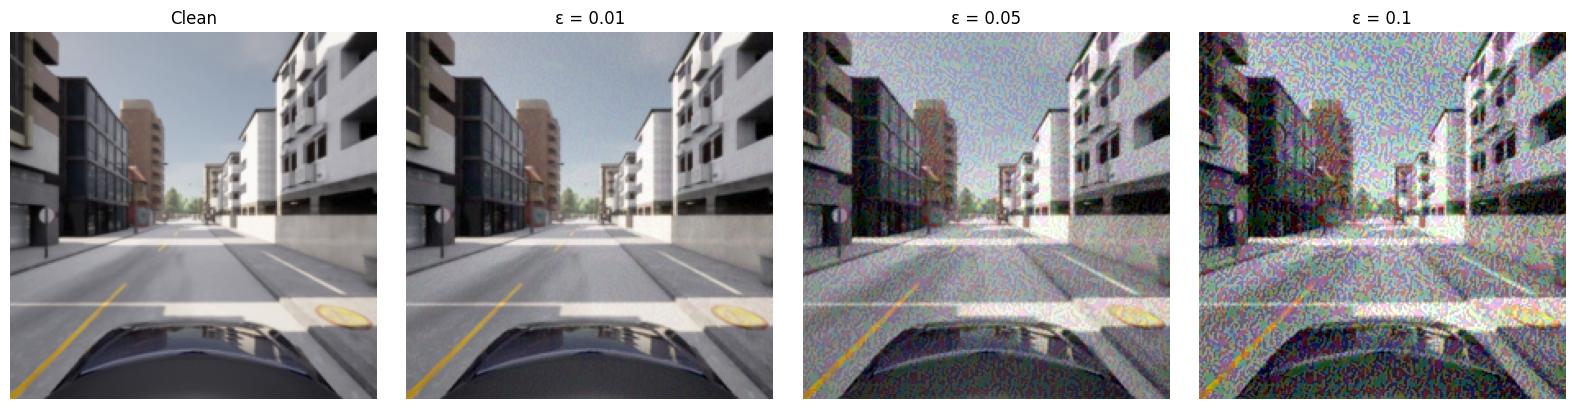

In [20]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(16,4)
)

titles = [
    "Clean",
    "ε = 0.01",
    "ε = 0.05",
    "ε = 0.1"
]

for ax, (img, eps, pred), title in zip(
    axes,
    results,
    titles
):

    img = img.squeeze().permute(1,2,0).numpy()

    ax.imshow(img)

    ax.set_title(title)

    ax.axis("off")

plt.tight_layout()
plt.show()